# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 1. Data Preparation

In [2]:
df = pd.read_csv('BostonHousing.csv')

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
X = df.drop('medv', axis=1)
y = df['medv']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [8]:
lr_preds = lr_model.predict(X_test)

In [9]:
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
print('MAE:', round(lr_mae, 4))
print('MSE:', round(lr_mse, 4))
print('RMSE:', round(lr_rmse, 4))

MAE: 3.8357
MSE: 28.5476
RMSE: 5.343


In [10]:
pd.Series(lr_model.coef_, index=X.columns)

,0
crim,-0.088505
zn,0.050293
indus,0.020348
chas,3.754271
nox,-17.748371
rm,3.247765
age,0.012001
dis,-1.409161
rad,0.263881
tax,-0.010344


### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [11]:
poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(X)
Xp_train, Xp_test, yp_train, yp_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [12]:
pr_model = LinearRegression()
pr_model.fit(Xp_train, yp_train)

LinearRegression()

In [13]:
pr_preds = pr_model.predict(Xp_test)

In [14]:
pr_mae = mean_absolute_error(yp_test, pr_preds)
pr_mse = mean_squared_error(yp_test, pr_preds)
pr_rmse = np.sqrt(pr_mse)
print('MAE:', round(pr_mae, 4))
print('MSE:', round(pr_mse, 4))
print('RMSE:', round(pr_rmse, 4))

MAE: 2.7017
MSE: 14.5331
RMSE: 3.8122


### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


In [15]:
print('Linear Regression:')
print(f'  MAE:  {round(lr_mae, 4)}')
print(f'  MSE:  {round(lr_mse, 4)}')
print(f'  RMSE: {round(lr_rmse, 4)}')
print()
print('Polynomial Regression (degree=2):')
print(f'  MAE:  {round(pr_mae, 4)}')
print(f'  MSE:  {round(pr_mse, 4)}')
print(f'  RMSE: {round(pr_rmse, 4)}')

Linear Regression:
  MAE:  3.8357
  MSE:  28.5476
  RMSE: 5.343

Polynomial Regression (degree=2):
  MAE:  2.7017
  MSE:  14.5331
  RMSE: 3.8122


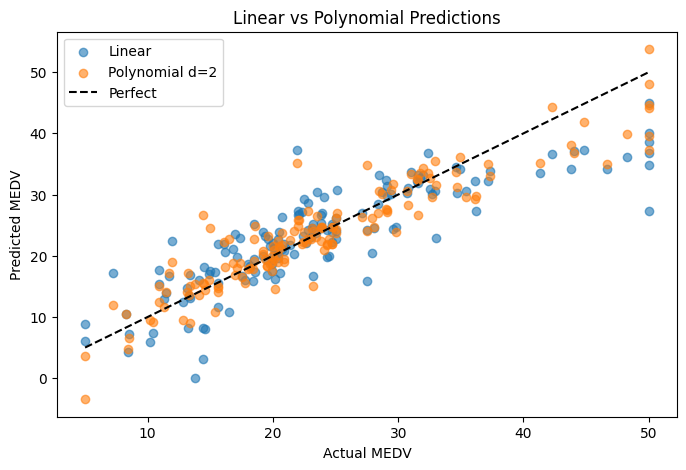

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_preds, label='Linear', alpha=0.6)
plt.scatter(yp_test, pr_preds, label='Polynomial d=2', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect')
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Linear vs Polynomial Predictions')
plt.legend()
plt.show()

In [17]:
# polynomial regression is the better model here
# housing prices dont have a purely linear relationship with features like
# crime rate, number of rooms, distance to employment etc.
# degree 2 captures the interactions between those features
# RMSE dropped from 5.343 to 3.812 which is a solid improvement
print('Polynomial regression is the better model')
print(f'RMSE improvement: {round(lr_rmse - pr_rmse, 4)}')

Polynomial regression is the better model
RMSE improvement: 1.5308
